In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import splprep, splev
from svgpathtools import Path, CubicBezier, wsvg

import os

In [44]:
def show(img: np.ndarray):
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")

In [45]:
def show_side_by_side_plt(images: list, labels: list = None, title="Comparison"):
    """Show a list of images side by side with matplotlib."""
    
    if labels is None:
        labels = [f"Image {i+1}" for i in range(len(images))]
    
    if len(images) != len(labels):
        raise ValueError("The number of images must match the number of labels.")
    
    num_images = len(images)
    
    
    plt.figure(figsize=(10, 5))
    
    for i, img in enumerate(images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.title(labels[i])
        plt.axis("off")
    
    plt.suptitle(title)
    plt.show()

In [46]:
def vertical_symmetric(img: np.ndarray) -> np.ndarray:
    """Làm đối xứng ảnh trái-phải bằng cách lấy giá trị min của các pixel đối xứng"""
    # Tạo bản copy để không thay đổi ảnh gốc
    img_array = img.copy()
    h, w = img_array.shape[:2]

    # Làm đối xứng trái-phải
    for y in range(h):
        for x in range(w // 2):
            left = img_array[y, x]
            right = img_array[y, w - x - 1]
            
            # Xử lý cho cả ảnh grayscale và RGB
            if len(img_array.shape) == 3:  # RGB
                min_value = np.minimum(left, right)
            else:  # Grayscale
                min_value = min(left, right)
            if min_value > 127:
                min_value = 255
            else:
                min_value = 0
            img_array[y, x] = min_value
            img_array[y, w - x - 1] = min_value
    
    return img_array

In [47]:
def horizontal_symmetric(img: np.ndarray) -> np.ndarray:
    """Làm đối xứng ảnh trên-dưới bằng cách lấy giá trị min của các pixel đối xứng"""
    # Tạo bản copy để không thay đổi ảnh gốc
    img_array = img.copy()
    h, w = img_array.shape[:2]

    # Làm đối xứng trên-dưới
    for y in range(h // 2):
        for x in range(w):
            top = img_array[y, x]
            bottom = img_array[h - y - 1, x]
            
            # Xử lý cho cả ảnh grayscale và RGB
            if len(img_array.shape) == 3:  # RGB
                min_value = np.minimum(top, bottom)
            else:  # Grayscale
                min_value = min(top, bottom)
            if min_value > 127:
                min_value = 255
            else:
                min_value = 0
            img_array[y, x] = min_value
            img_array[h - y - 1, x] = min_value
    
    return img_array

In [48]:
def centripetal_symmetric(img: np.ndarray) -> np.ndarray:
    new_img = vertical_symmetric(img)
    new_img = horizontal_symmetric(new_img)
    return new_img

In [49]:
def get_contours(img: np.ndarray):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
    
    return contour_img, contours

In [50]:
def draw_quadratic_beziers_from_contours(contours, img_shape, color=(0, 0, 255), thickness=2, step=0.02):
    """
    Draws quadratic Bézier curves for each contour.
    Each curve is defined by every 3 consecutive points in the contour.

    Args:
        contours: list of contour arrays (from cv2.findContours)
        img_shape: shape of the output image (e.g. original image.shape)
        color: curve color (BGR)
        thickness: line thickness
        step: curve sampling interval (smaller = smoother)

    Returns:
        img: image with Bézier curves drawn
    """
    img = np.zeros(img_shape, dtype=np.uint8)

    for contour in contours:
        # Flatten contour shape (N,1,2) -> (N,2)
        pts = contour.reshape(-1, 2)

        # Draw each quadratic Bézier segment from 3 consecutive points
        for i in range(0, len(pts) - 2, 2):
            p0, p1, p2 = pts[i], pts[i + 1], pts[i + 2]

            # Sample curve points
            curve_points = []
            for t in np.arange(0, 1 + step, step):
                x = int((1 - t)**2 * p0[0] + 2*(1 - t)*t*p1[0] + t**2 * p2[0])
                y = int((1 - t)**2 * p0[1] + 2*(1 - t)*t*p1[1] + t**2 * p2[1])
                curve_points.append((x, y))

            # Draw polyline
            for j in range(len(curve_points) - 1):
                cv2.line(img, curve_points[j], curve_points[j + 1], color, thickness)

    return img


In [51]:
def contours_to_bezier_vectors(contours):
    """
    Convert contours (from cv2.findContours) into a list of lists of quadratic Bézier vectors.
    Each contour becomes a closed shape — last point connects back to the first.

    Each vector: ("Q", P0, P1, P2)
    """
    all_vectors = []

    for contour in contours:
        points = contour.reshape(-1, 2)
        n = len(points)
        if n < 3:
            all_vectors.append([])  # keep empty contour structure
            continue


        points = np.vstack([points, points[0]])  # connect last to first

        contour_vectors = []
        for i in range(0, len(points) - 2, 3):
            p0, p1, p2 = map(tuple, points[i:i+3])
            contour_vectors.append(("Q", p0, p1, p2))


        remain = (len(points) - 1) % 3
        if remain:
            tail = points[-3:] if len(points) >= 3 else points
            p0, p1, p2 = map(tuple, [tail[0], tail[-2], tail[-1]])
            contour_vectors.append(("Q", p0, p1, p2))

        all_vectors.append(contour_vectors)

    return all_vectors


In [52]:
def sample_bezier_vectors(all_vectors, samples_per_curve=20):
    """
    Sample a list of contours' Bézier vectors into point arrays.

    Args:
        all_vectors: list of lists of ("Q", P0, P1, P2)
        samples_per_curve: number of points per curve

    Returns:
        list of numpy arrays, one per contour
    """
    all_sampled = []

    for vectors in all_vectors:
        contour_points = []
        for cmd, p0, p1, p2 in vectors:
            if cmd != "Q":
                continue
            p0, p1, p2 = np.array(p0), np.array(p1), np.array(p2)
            t = np.linspace(0, 1, samples_per_curve)[:, None]
            curve = (1 - t)**2 * p0 + 2 * (1 - t) * t * p1 + t**2 * p2
            contour_points.append(curve)

        if contour_points:
            all_sampled.append(np.vstack(contour_points))
        else:
            all_sampled.append(np.zeros((0, 2)))

    return all_sampled


[Centripetal Catmull–Rom spline](https://en.wikipedia.org/wiki/Centripetal_Catmull%E2%80%93Rom_spline)

Vẽ hàm bậc 3 giữa các điểm của contour 

In [ ]:
def smooth_contour(cnt, smooth_factor=0.2):
    cnt = cnt.squeeze()
    if not np.array_equal(cnt[0], cnt[-1]):
        cnt = np.vstack([cnt, cnt[0]])

    n = len(cnt)
    beziers = []

    for i in range(n - 1):
        p0 = cnt[i - 1].astype(float)
        p1 = cnt[i].astype(float)
        p2 = cnt[(i + 1) % n].astype(float)
p3 = cnt[(i + 2) % n].astype(float)

        # Catmull–Rom to Cubic Bézier conversion
        c1 = p1 + (p2 - p0) * smooth_factor
        c2 = p2 - (p3 - p1) * smooth_factor

        seg = CubicBezier(
            complex(p1[0], p1[1]),
            complex(c1[0], c1[1]),
            complex(c2[0], c2[1]),
            complex(p2[0], p2[1])
        )
        beziers.append(seg)

    return Path(*beziers)


In [54]:
# Gộp tất cả paths vào một group (layer) trong SVG
import xml.etree.ElementTree as ET

tree = ET.parse("output_cubic.svg")
root = tree.getroot()

# Tìm tất cả path elements
paths_in_svg = []
for elem in root.iter():
    tag = elem.tag
    if tag.endswith('path') or tag == 'path':
        paths_in_svg.append(elem)

if paths_in_svg:
    # Tạo group mới
    g = ET.Element('g', {'id': 'contour-layer'})
    
    # Lưu parent của mỗi path trước khi remove
    path_parents = {}
    for path in paths_in_svg:
        for parent in root.iter():
            if path in list(parent):
                path_parents[path] = parent
                break
    
    # Di chuyển tất cả paths vào group
    for path in paths_in_svg:
        if path in path_parents:
            path_parents[path].remove(path)
        g.append(path)
    
    # Thêm group vào root (sau defs nếu có)
    defs = root.find('{http://www.w3.org/2000/svg}defs')
    if defs is not None:
        idx = list(root).index(defs) + 1
        root.insert(idx, g)
    else:
        root.insert(0, g)
    
    # Lưu lại file
    tree.write("output_cubic.svg", encoding='utf-8', xml_declaration=True)
    print(f"Đã gộp {len(paths_in_svg)} paths vào 1 layer trong output_cubic.svg")
else:
    print("Không tìm thấy paths trong SVG")



Đã gộp 6 paths vào 1 layer trong output_cubic.svg


Tìm thấy 6 contour(s) của vật thể đen (bao gồm lỗ)
Tổng số contours để xuất: 6


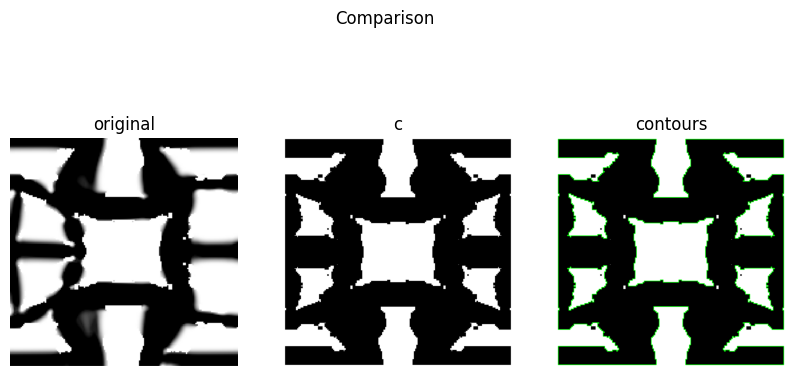

Detected 743 corner points


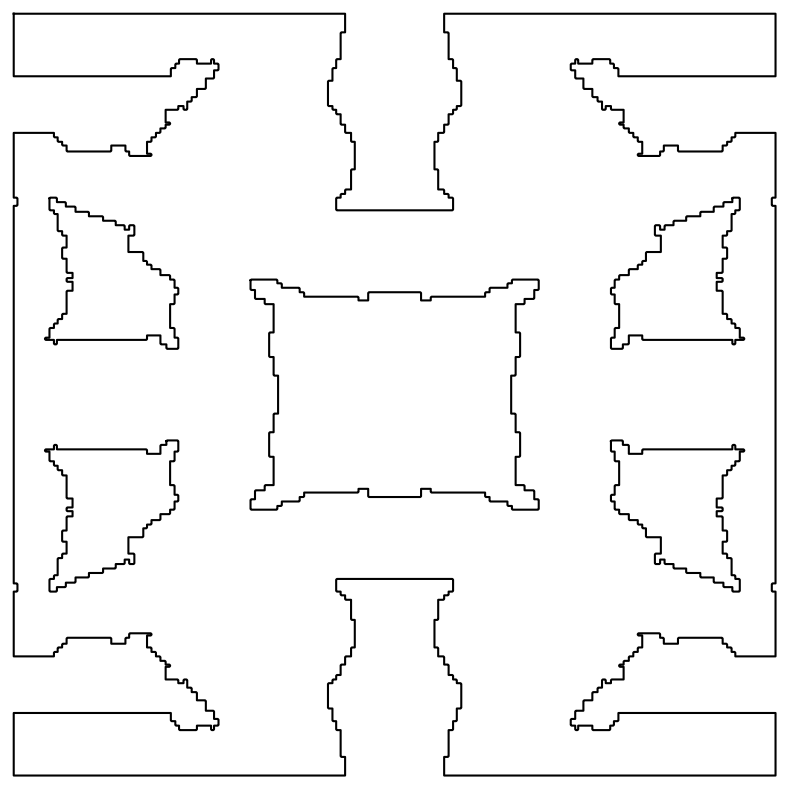

Complete. Saved 6 contours to output_cubic.svg (black fill)


In [55]:
if __name__ == "__main__":
    img = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 254, 255, cv2.THRESH_BINARY)
    
    

    vsymmetric = vertical_symmetric(binary)
    hsymmetric = horizontal_symmetric(vsymmetric)
    csymmetric = centripetal_symmetric(hsymmetric)
    
    
    # Thêm 5 pixel border màu trắng (255) vào ngoài cùng ảnh
    border_size = 5
    csymmetric = cv2.copyMakeBorder(csymmetric, border_size, border_size, border_size, border_size, 
                                cv2.BORDER_CONSTANT, value=255)
    
    # Đảo ngược để vật thể đen thành trắng (foreground)
    csymmetric_inv = cv2.bitwise_not(csymmetric)
    
    # Lấy TẤT CẢ contours (bao gồm cả lỗ bên trong) dùng RETR_TREE
    contours_all, hierarchy = cv2.findContours(csymmetric_inv, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Lọc: giữ contour ngoài cùng của vật thể + contours của lỗ bên trong
    h, w = csymmetric.shape
    img_area = h * w
    contours = []
    
    if hierarchy is not None:
        hierarchy = hierarchy[0]  # reshape từ (1, N, 4) -> (N, 4)
        for i, cnt in enumerate(contours_all):
            area = cv2.contourArea(cnt)
            # Bỏ contour border (quá lớn) và contours quá nhỏ
            if 1000 < area < img_area * 0.98:
                contours.append(cnt)
    
    print(f"Tìm thấy {len(contours)} contour(s) của vật thể đen (bao gồm lỗ)")
    
    # Vẽ preview trên ảnh gốc (chưa đảo)
    contour_img = cv2.cvtColor(csymmetric, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
    
    # Bỏ bước lọc thứ 2 để giữ tất cả contours (đã lọc ở trên)
    print(f"Tổng số contours để xuất: {len(contours)}")

    # Hiển thị 3 ảnh đầu và contours
    show_side_by_side_plt(
        [img, csymmetric, contour_img], 
        labels=["original", "c", "contours"]
    )

    # Phát hiện điểm góc (gradient thay đổi đột ngột) trên ảnh đối xứng
    corners = cv2.goodFeaturesToTrack(csymmetric, maxCorners=1000, qualityLevel=0.01,
                                      minDistance=5, blockSize=3, useHarrisDetector=True, k=0.04)
    corner_pts = []
    if corners is not None:
        corners = np.int32(corners)
        for c in corners:
            x, y = c.ravel()
            corner_pts.append((x, y))
    print(f"Detected {len(corner_pts)} corner points")

    # Vẽ trực tiếp contours gốc (không làm mượt) và đánh dấu góc màu đỏ
    fig, ax = plt.subplots(figsize=(8, 8))
    h, w = csymmetric.shape
    for cnt in contours:
        pts = cnt.reshape(-1, 2)
        if len(pts) == 0:
            continue
        if not np.array_equal(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])
        ax.plot(pts[:, 0], pts[:, 1], linewidth=1.5, color='black')
    # if corner_pts:
    #     xs, ys = zip(*corner_pts)
    #     ax.scatter(xs, ys, s=12, c='red', marker='o', label='Corners')
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Xuất SVG từ contours gốc (đường thẳng, không làm mượt)
    dir = './cubic'
    if not os.path.exists(dir):
        os.makedirs(dir)

    from svgpathtools import Line
    paths = []
    for cnt in contours:
        pts = cnt.reshape(-1, 2)
        if len(pts) < 2:
            continue
        if not np.array_equal(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])
        segments = []
        for i in range(len(pts) - 1):
            p1 = complex(pts[i][0], pts[i][1])
            p2 = complex(pts[i+1][0], pts[i+1][1])
            segments.append(Line(p1, p2))
        if segments:
            paths.append(Path(*segments))

    attributes = [{'fill': 'red', 'stroke': 'black', 'stroke-width': '1'} for _ in paths]
    wsvg(paths=paths, filename="output_cubic.svg", attributes=attributes)
    print(f"Complete. Saved {len(paths)} contours to output_cubic.svg (black fill)")

1599.7644996643066
Số corner tìm được: 10


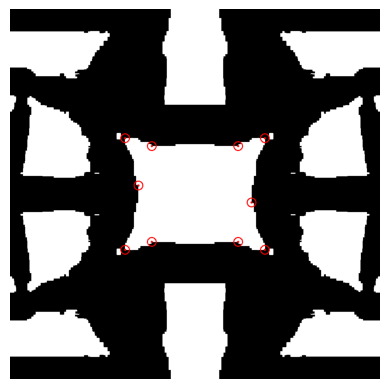

In [56]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE) 
vsymmetric = vertical_symmetric(img_binary) 
hsymmetric = horizontal_symmetric(vsymmetric) 
csymmetric = centripetal_symmetric(hsymmetric) 
img_binary = csymmetric 
# img_binary: ảnh nhị phân (0 / 255) 
contours, _ = cv2.findContours( img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE ) 
cnt = max(contours, key=cv2.contourArea) 
# epsilon tỉ lệ theo chu vi (rất quan trọng) 
perimeter = cv2.arcLength(cnt, True) 
print(perimeter)
epsilon = 0.01 * perimeter 
# 0.5% – 2% là đẹp cho ảnh topo 
cnt_smooth = cv2.GaussianBlur(cnt.astype(np.float32), (5,1), 0) 
cnt_smooth = cnt_smooth.astype(np.int32) 
approx = cv2.approxPolyDP(cnt_smooth, epsilon, True) 
print(f"Số corner tìm được: {len(approx)}") 
vis = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2BGR) 
for p in approx[:12]: 
    x, y = p[0] 
    cv2.circle(vis, (x, y), 3, (0, 0, 255), -1) 
    cv2.circle(vis, (x, y), 12, (0, 0, 255), 2) 
# nhớ đổi màu trước khi imshow 
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB) 
plt.imshow(vis_rgb) 
plt.axis("off") 
plt.show()

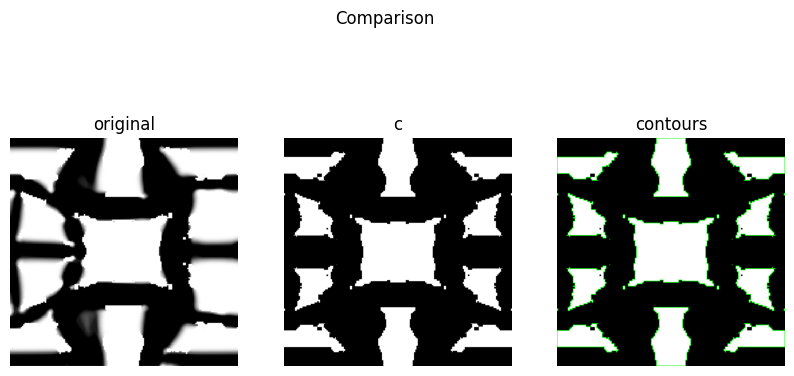

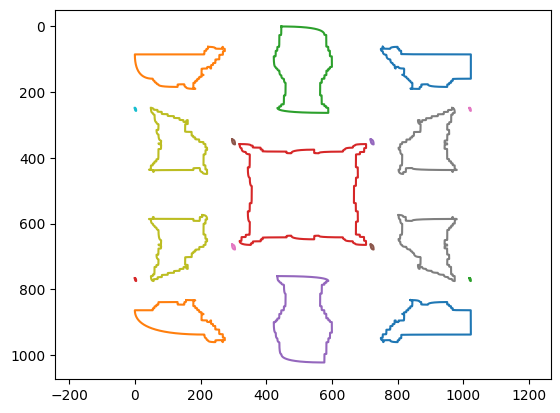

In [57]:
if __name__ == "__main__":
    img = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 254, 255, cv2.THRESH_BINARY)

    vsymmetric = vertical_symmetric(binary)
    hsymmetric = horizontal_symmetric(vsymmetric)
    csymmetric = centripetal_symmetric(hsymmetric)
    contour_img, contours = get_contours(csymmetric)
    small_area = 1000
    # show_side_by_side_plt(
    #     [img, binary, vsymmetric, hsymmetric, csymmetric, contour_img], 
    #     labels=["original", "threshold", "v", "h", "c", "contours"]
    # )

    show_side_by_side_plt(
        [img, csymmetric, contour_img], 
        labels=["original", "c", "contours"]
    )

    # paths = contours_to_quadratic_beziers(contours)
    # wsvg(paths, filename='output.svg')
    # rendered = render_svg(paths, 1080, 1080)
    # cv2.imshow("Bezier Render", rendered)
    # cv2.waitKey(0)

    all_vectors = contours_to_bezier_vectors(contours)
    all_sampled = sample_bezier_vectors(all_vectors, samples_per_curve=1000)
    for pts in all_sampled:
        plt.plot(pts[:, 0], pts[:, 1])
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.show()




    dir = './cubic'
    if not os.path.exists(dir):
        os.makedirs(dir)

    # Ramer–Douglas–Peucker algorithm
    # epsilon lớn => các cạnh càng mượt

    # for i in range(1, 10):
    #     epsilon = i / 1000
    #     paths = []
        
    #     for cnt in contours:
    #         approx = cv2.approxPolyDP(cnt, epsilon, closed=True)
    #         path = smooth_contour(approx, smooth_factor=0.2)
    #         paths.append(path)
        
    #     filename = os.path.join(dir, f"{epsilon:.3f}.svg")
        
    #     attributes = [{'fill': 'white', 'stroke': 'nonesmo'} for _ in paths]
    #     wsvg(paths=paths, filename=filename, attributes=attributes)
        
    paths = []
    for cnt in contours:
        perimeter = cv2.arcLength(cnt, True)
        epsilon = 1
        approx = cv2.approxPolyDP(cnt, epsilon, closed=True)

        path = smooth_contour(approx, smooth_factor=0.2)
        paths.append(path)


    attributes = [{'fill': 'white', 'stroke': 'none'} for _ in paths]
    wsvg(paths=paths, filename="cubic-1.svg", attributes=attributes)

1939.847759962082
Số corner tìm được: 12


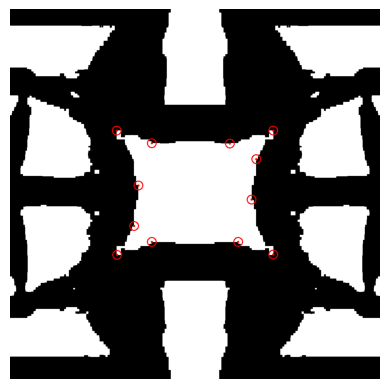

In [58]:
# Smooth contour và tìm corner points
img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)
vsymmetric = vertical_symmetric(img_binary)
hsymmetric = horizontal_symmetric(img_binary)
csymmetric = centripetal_symmetric(img_binary)
img_binary = vsymmetric
# img_binary: ảnh nhị phân (0 / 255)
contours, _ = cv2.findContours(img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

cnt = max(contours, key=cv2.contourArea)
# epsilon tỉ lệ theo chu vi (rất quan trọng)
perimeter = cv2.arcLength(cnt, True)
print(perimeter)
epsilon = 0.01 * perimeter  # 0.5% – 2% là đẹp cho ảnh topo
cnt_smooth = cv2.GaussianBlur(cnt.astype(np.float32), (5, 1), 0)
cnt_smooth = cnt_smooth.astype(np.int32)
approx = cv2.approxPolyDP(cnt_smooth, epsilon, True)
print(f"Số corner tìm được: {len(approx)}")
vis = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2BGR)
for p in approx[:12]:
    x, y = p[0]
    cv2.circle(vis, (x, y), 3, (0, 0, 255), -1)
    cv2.circle(vis, (x, y), 12, (0, 0, 255), 2)

# nhớ đổi màu trước khi imshow
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.imshow(vis_rgb)
plt.axis("off")
plt.show()


1599.7644996643066
Số corner tìm được: 10


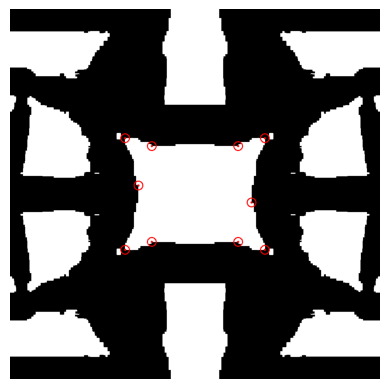

In [59]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE) 
vsymmetric = vertical_symmetric(img_binary) 
hsymmetric = horizontal_symmetric(vsymmetric) 
csymmetric = centripetal_symmetric(hsymmetric) 
img_binary = csymmetric 
# img_binary: ảnh nhị phân (0 / 255) 
contours, _ = cv2.findContours( img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE ) 
cnt = max(contours, key=cv2.contourArea) 
# epsilon tỉ lệ theo chu vi (rất quan trọng) 
perimeter = cv2.arcLength(cnt, True) 
print(perimeter)
epsilon = 0.01 * perimeter 
# 0.5% – 2% là đẹp cho ảnh topo 
cnt_smooth = cv2.GaussianBlur(cnt.astype(np.float32), (5,1), 0) 
cnt_smooth = cnt_smooth.astype(np.int32) 
approx = cv2.approxPolyDP(cnt_smooth, epsilon, True) 
print(f"Số corner tìm được: {len(approx)}") 
vis = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2BGR) 
for p in approx[:12]: 
    x, y = p[0] 
    cv2.circle(vis, (x, y), 3, (0, 0, 255), -1) 
    cv2.circle(vis, (x, y), 12, (0, 0, 255), 2) 
# nhớ đổi màu trước khi imshow 
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB) 
plt.imshow(vis_rgb) 
plt.axis("off") 
plt.show()

Filled 12 tiny contours (area < 1000)
Phân tích gradient và tìm đỉnh góc cho 11 contour(s):
  Contour 1: 20 đỉnh
  Contour 2: 20 đỉnh
  Contour 3: 22 đỉnh
  Contour 4: 30 đỉnh
  Contour 5: 30 đỉnh
  Contour 6: 44 đỉnh
  Contour 7: 30 đỉnh
  Contour 8: 30 đỉnh
  Contour 9: 20 đỉnh
  Contour 10: 20 đỉnh
  Contour 11: 22 đỉnh


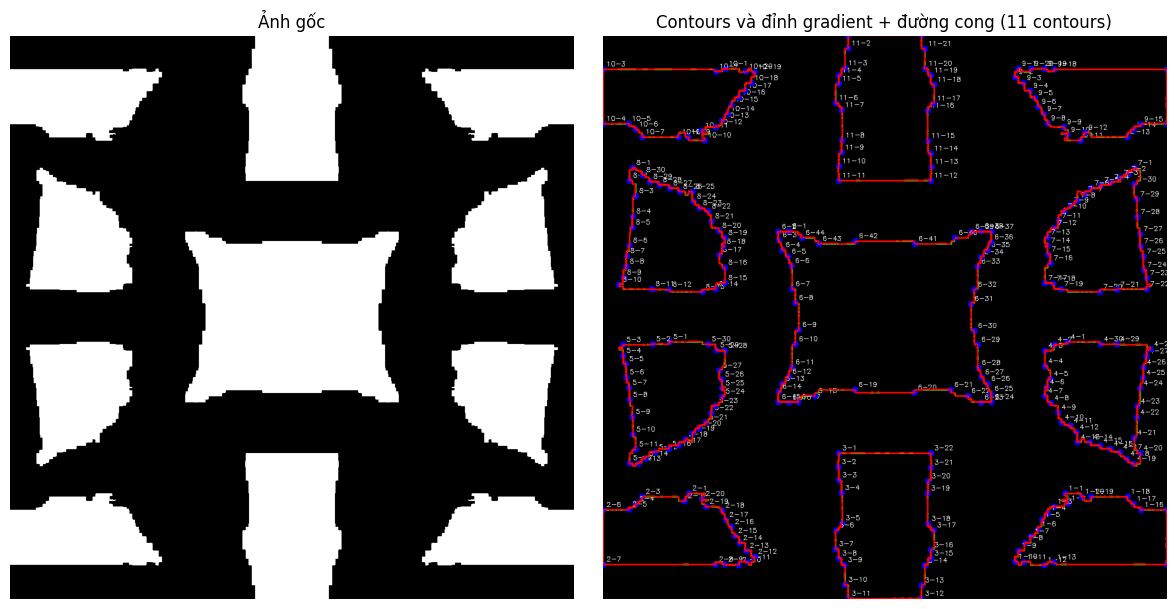

In [60]:
# Hiển thị ảnh gốc và ảnh có contours
import cv2
import numpy as np
import matplotlib.pyplot as plt

# img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)

# Đối xứng nếu cần
vsymmetric = vertical_symmetric(img_binary)
hsymmetric = horizontal_symmetric(vsymmetric)
csymmetric = centripetal_symmetric(hsymmetric)
img_binary = csymmetric
contours, _ = cv2.findContours(
    img_binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)
small_area = 1000
removed = 0
for cnt in contours:
    if cv2.contourArea(cnt) < small_area:
        cv2.drawContours(img_binary, [cnt], -1, 0, thickness=-1)
        removed += 1
if removed:
    print(f"Filled {removed} tiny contours (area < {small_area})")

# Tìm contours lại sau khi loại bỏ contours nhỏ
contours, _ = cv2.findContours(img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# Hàm: tìm đỉnh góc dựa trên gradient (thay đổi góc đột ngột giữa các đoạn)
def find_corners_by_gradient(contour, angle_threshold=30, min_dist=20):
    pts = contour.reshape(-1, 2).astype(float)
    n = len(pts)
    if n < 4:
        return [0]
    angles = []
    for i in range(n):
        v1 = pts[i] - pts[(i-1) % n]
        v2 = pts[(i+1) % n] - pts[i]
        a1 = np.arctan2(v1[1], v1[0])
        a2 = np.arctan2(v2[1], v2[0])
        angle_diff = np.abs(np.degrees((a2 - a1 + np.pi) % (2*np.pi) - np.pi))
        angles.append(angle_diff)
    angles = np.array(angles)
    corners = []
    for i in range(n):
        if angles[i] > angle_threshold:
            if angles[i] >= angles[(i-1) % n] and angles[i] >= angles[(i+1) % n]:
                corners.append(i)
    filtered = []
    for c in corners:
        too_close = any(np.linalg.norm(pts[c] - pts[fc]) < min_dist for fc in filtered)
        if not too_close:
            filtered.append(c)
    return sorted(filtered)

# Hàm: vẽ đường cong mượt giữa 2 đỉnh (dùng spline qua các điểm trung gian)
def draw_curve_segment(img, pts, idx_start, idx_end, color, thickness, num_samples=20):
    from scipy.interpolate import splprep, splev
    n = len(pts)
    segment = []
    i = idx_start
    while True:
        segment.append(pts[i])
        if i == idx_end:
            break
        i = (i + 1) % n
    segment = np.array(segment, dtype=float)
    if len(segment) < 2:
        return
    if len(segment) >= 4:
        tck, u = splprep([segment[:, 0], segment[:, 1]], s=0, per=0)
        u_new = np.linspace(0, 1, num_samples)
        x_new, y_new = splev(u_new, tck)
        pts_curve = np.column_stack([x_new, y_new]).astype(np.int32)
    else:
        pts_curve = segment.astype(np.int32)
    for j in range(len(pts_curve) - 1):
        cv2.line(img, tuple(pts_curve[j]), tuple(pts_curve[j+1]), color, thickness)

# Phân tích gradient và tìm đỉnh góc cho từng contour
all_vertices = []
print(f"Phân tích gradient và tìm đỉnh góc cho {len(contours)} contour(s):")
for idx, cnt in enumerate(contours):
    corners = find_corners_by_gradient(cnt, angle_threshold=25, min_dist=15)
    all_vertices.append(corners)
    print(f"  Contour {idx+1}: {len(corners)} đỉnh")

# Chuẩn bị ảnh gốc
img_original = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2RGB)

# Chuẩn bị ảnh chỉ có contours (nền đen)
h, w = img_binary.shape
img_contours_only = np.zeros((h, w, 3), dtype=np.uint8)
cv2.drawContours(img_contours_only, contours, -1, (0, 255, 0), 2)

# Vẽ đỉnh góc + đường cong giữa các đỉnh cho từng contour
for idx, cnt in enumerate(contours):
    pts = cnt.reshape(-1, 2)
    corners = all_vertices[idx]
    if len(corners) < 2:
        continue
    for i, c in enumerate(corners):
        pt = tuple(pts[c].astype(int))
        cv2.circle(img_contours_only, pt, 6, (0, 0, 255), -1)
        cv2.putText(img_contours_only, f"{idx+1}-{i+1}", (pt[0]+6, pt[1]-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
    for i in range(len(corners)):
        idx_start = corners[i]
        idx_end = corners[(i + 1) % len(corners)]
        draw_curve_segment(img_contours_only, pts, idx_start, idx_end, (255, 0, 0), 2)

# Hiển thị 2 ảnh cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Ảnh gốc
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[0].axis('off')

# Ảnh chỉ có contours và hình tứ giác bao trùm
axes[1].imshow(img_contours_only)
axes[1].set_title(f'Contours và đỉnh gradient + đường cong ({len(contours)} contours)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


Tìm hình tứ giác bao trùm cho 11 contour(s):

Contour 1 - 4 điểm góc:
  Điểm 1: (747, 962)
  Điểm 2: (747, 832)
  Điểm 3: (1022, 832)
  Điểm 4: (1022, 962)

Contour 2 - 4 điểm góc:
  Điểm 1: (0, 962)
  Điểm 2: (0, 832)
  Điểm 3: (274, 832)
  Điểm 4: (274, 962)

Contour 3 - 4 điểm góc:
  Điểm 1: (422, 759)
  Điểm 2: (601, 759)
  Điểm 3: (601, 1023)
  Điểm 4: (422, 1023)

Contour 4 - 4 điểm góc:
  Điểm 1: (784, 765)
  Điểm 2: (804, 545)
  Điểm 3: (994, 562)
  Điểm 4: (974, 782)

Contour 5 - 4 điểm góc:
  Điểm 1: (28, 562)
  Điểm 2: (218, 545)
  Điểm 3: (238, 765)
  Điểm 4: (48, 782)

Contour 6 - 4 điểm góc:
  Điểm 1: (318, 356)
  Điểm 2: (705, 356)
  Điểm 3: (705, 667)
  Điểm 4: (318, 667)

Contour 7 - 4 điểm góc:
  Điểm 1: (784, 257)
  Điểm 2: (974, 240)
  Điểm 3: (994, 460)
  Điểm 4: (804, 477)

Contour 8 - 4 điểm góc:
  Điểm 1: (28, 460)
  Điểm 2: (48, 240)
  Điểm 3: (238, 257)
  Điểm 4: (218, 477)

Contour 9 - 4 điểm góc:
  Điểm 1: (748, 61)
  Điểm 2: (1023, 61)
  Điểm 3: (1023, 191)

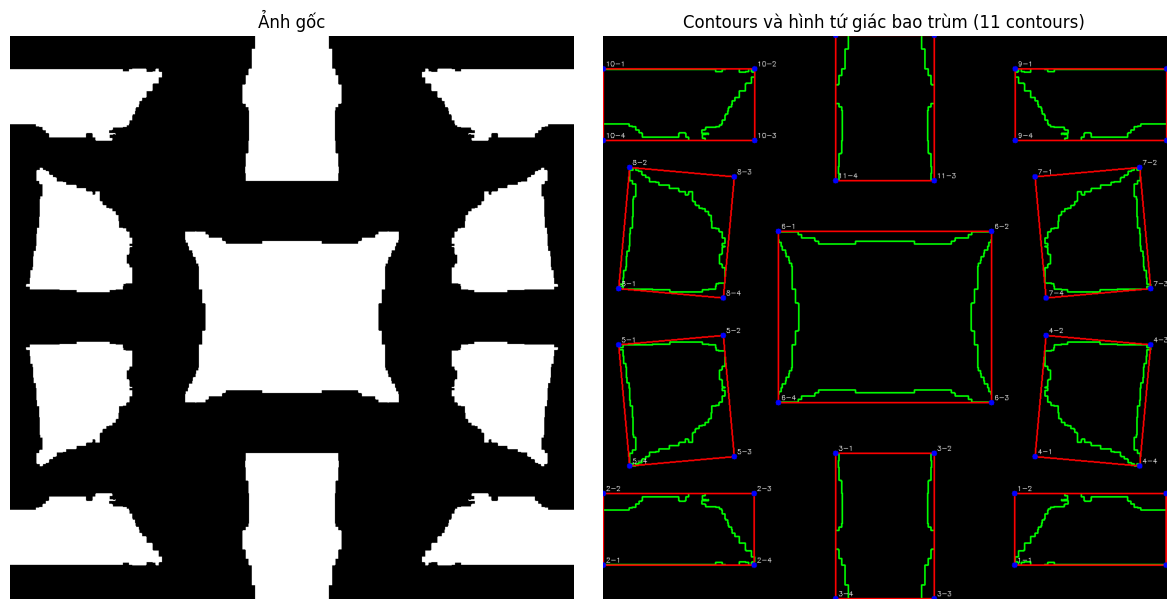

In [61]:
# Hiển thị ảnh gốc và ảnh có contours
import cv2
import numpy as np
import matplotlib.pyplot as plt

# img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)

# Đối xứng nếu cần
vsymmetric = vertical_symmetric(img_binary)
hsymmetric = horizontal_symmetric(vsymmetric)
csymmetric = centripetal_symmetric(hsymmetric)
img_binary = csymmetric
contours, _ = cv2.findContours(
    img_binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)
small_area = 1000
removed = 0
for cnt in contours:
    if cv2.contourArea(cnt) < small_area:
        cv2.drawContours(img_binary, [cnt], -1, 0, thickness=-1)
        removed += 1
if removed:
    print(f"Filled {removed} tiny contours (area < {small_area})")

# Tìm contours lại sau khi loại bỏ contours nhỏ
contours, _ = cv2.findContours(img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# Tìm 4 điểm góc để vẽ hình tứ giác bao trùm cho tất cả contours
# Sử dụng minAreaRect để tìm hình chữ nhật nhỏ nhất có thể xoay
all_boxes = []
print(f"Tìm hình tứ giác bao trùm cho {len(contours)} contour(s):")
for idx, cnt in enumerate(contours):
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)  # Lấy 4 góc của hình chữ nhật
    box = box.astype(np.int32)
    all_boxes.append(box)
    
    print(f"\nContour {idx+1} - 4 điểm góc:")
    for i, point in enumerate(box):
        print(f"  Điểm {i+1}: ({point[0]}, {point[1]})")

# Chuẩn bị ảnh gốc
img_original = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2RGB)

# Chuẩn bị ảnh chỉ có contours (nền đen)
h, w = img_binary.shape
img_contours_only = np.zeros((h, w, 3), dtype=np.uint8)  # Nền đen
cv2.drawContours(img_contours_only, contours, -1, (0, 255, 0), 2)

# Vẽ hình tứ giác bao trùm cho tất cả contours
for idx, box in enumerate(all_boxes):
    cv2.drawContours(img_contours_only, [box], -1, (255, 0, 0), 2)  # Màu đỏ cho hình tứ giác
    # Vẽ các điểm góc
    for i, point in enumerate(box):
        cv2.circle(img_contours_only, tuple(point), 5, (0, 0, 255), -1)  # Điểm màu đỏ
        cv2.putText(img_contours_only, f"{idx+1}-{i+1}", (point[0]+5, point[1]-5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

# Hiển thị 2 ảnh cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Ảnh gốc
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[0].axis('off')

# Ảnh chỉ có contours và hình tứ giác bao trùm
axes[1].imshow(img_contours_only)
axes[1].set_title(f'Contours và hình tứ giác bao trùm ({len(contours)} contours)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


Filled 12 tiny contours (area < 1000)
Số corner tìm được: 10


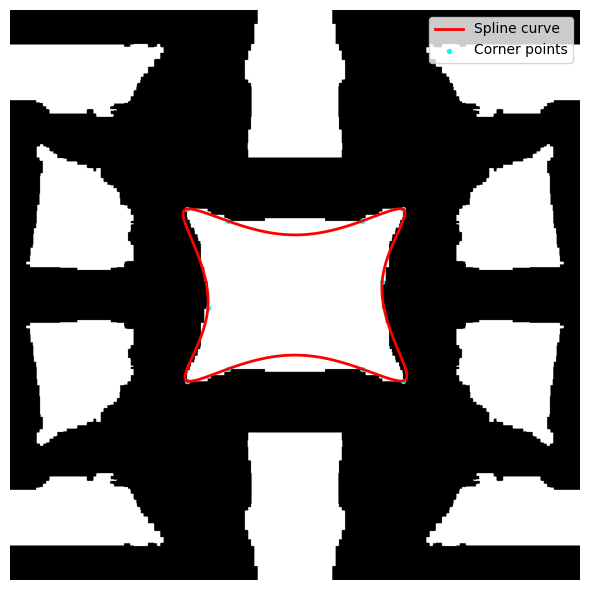

In [62]:
# Vẽ spline nối các điểm góc và overlay trực tiếp lên ảnh
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)

# Đối xứng nếu cần
vsymmetric = vertical_symmetric(img_binary)
hsymmetric = horizontal_symmetric(vsymmetric)
csymmetric = centripetal_symmetric(hsymmetric)
img_binary = csymmetric
contours, _ = cv2.findContours(
    img_binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)
small_area = 1000
removed = 0
for cnt in contours:
    if cv2.contourArea(cnt) < small_area:
        cv2.drawContours(img_binary, [cnt], -1, 0, thickness=-1)
        removed += 1
if removed:
    print(f"Filled {removed} tiny contours (area < {small_area})")
    # contour_img, contours = get_contours(img_binary)
# Tìm contours (giữ nguyên, không làm mượt)
contours, _ = cv2.findContours(img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = max(contours, key=cv2.contourArea)

# Smooth nhẹ contour và tìm corner bằng approxPolyDP
perimeter = cv2.arcLength(cnt, True)
epsilon = 0.01 * perimeter  # 1% chu vi
cnt_smooth = cv2.GaussianBlur(cnt.astype(np.float32), (5, 1), 0).astype(np.int32)
approx = cv2.approxPolyDP(cnt_smooth, epsilon, True)
print(f"Số corner tìm được: {len(approx)}")

# Tính spline nối các điểm góc
pts = approx[:, 0, :]
if not np.array_equal(pts[0], pts[-1]):
    pts = np.vstack([pts, pts[0]])
curve_x, curve_y = None, None
try:
    k = min(3, len(pts) - 1)
    tck, u = splprep([pts[:, 0], pts[:, 1]], s=0, per=True, k=k)
    unew = np.linspace(0, 1, 400)
    curve_x, curve_y = splev(unew, tck)
except Exception as e:
    print("Spline fitting failed:", e)

# Chuẩn bị ảnh nền và vẽ overlay
vis = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2BGR)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(vis_rgb)
if curve_x is not None:
    plt.plot(curve_x, curve_y, 'r-', linewidth=2, label='Spline curve')
else:
    plt.plot(pts[:, 0], pts[:, 1], 'r-', linewidth=2, label='Polyline')
plt.scatter(pts[:, 0], pts[:, 1], s=8, c='cyan', label='Corner points')
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')
plt.axis('off')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


Filled 12 tiny contours (area < 1000)
Tổng số corner tìm được từ 11 contour(s): 126


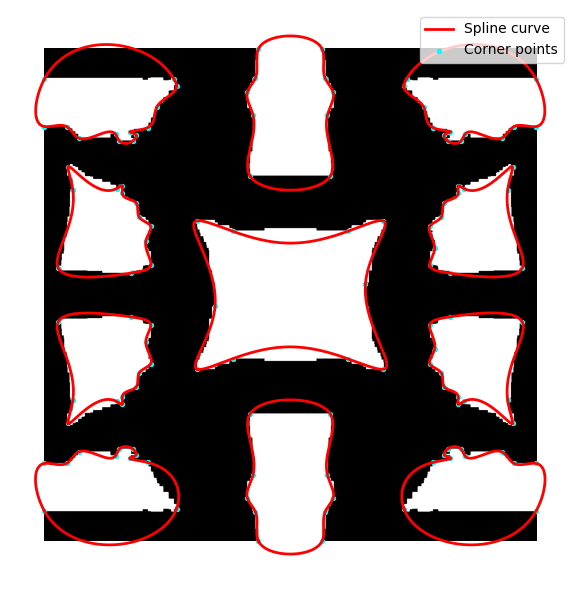

In [63]:
# Vẽ spline nối các điểm góc và overlay trực tiếp lên ảnh
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

img_binary = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)

# Đối xứng nếu cần
vsymmetric = vertical_symmetric(img_binary)
hsymmetric = horizontal_symmetric(vsymmetric)
csymmetric = centripetal_symmetric(hsymmetric)
img_binary = csymmetric
contours, _ = cv2.findContours(
    img_binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)
small_area = 1000
removed = 0
for cnt in contours:
    if cv2.contourArea(cnt) < small_area:
        cv2.drawContours(img_binary, [cnt], -1, 0, thickness=-1)
        removed += 1
if removed:
    print(f"Filled {removed} tiny contours (area < {small_area})")
    # contour_img, contours = get_contours(img_binary)
# Tìm contours (giữ nguyên, không làm mượt)
contours, _ = cv2.findContours(img_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# Chuẩn bị ảnh nền và vẽ overlay (di chuyển ra ngoài vòng lặp)
vis = cv2.cvtColor(img_binary, cv2.COLOR_GRAY2BGR)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(vis_rgb)

# Xử lý từng contour: tìm điểm góc và vẽ spline
all_corner_count = 0
for idx, cnt in enumerate(contours):
    # Smooth nhẹ contour và tìm corner bằng approxPolyDP
    perimeter = cv2.arcLength(cnt, True)
    epsilon = 0.01 * perimeter  # 1% chu vi
    cnt_smooth = cv2.GaussianBlur(cnt.astype(np.float32), (5, 1), 0).astype(np.int32)
    approx = cv2.approxPolyDP(cnt_smooth, epsilon, True)
    all_corner_count += len(approx)

    # Tính spline nối các điểm góc
    pts = approx[:, 0, :]
    if len(pts) < 2:
        continue
    if not np.array_equal(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])
    curve_x, curve_y = None, None
    try:
        k = min(3, len(pts) - 1)
        if k >= 1:
            tck, u = splprep([pts[:, 0], pts[:, 1]], s=0, per=True, k=k)
            unew = np.linspace(0, 1, 400)
            curve_x, curve_y = splev(unew, tck)
    except Exception as e:
        print(f"Spline fitting failed for contour {idx}:", e)

    # Vẽ spline hoặc polyline cho contour này (trên cùng 1 ảnh)
    if curve_x is not None:
        plt.plot(curve_x, curve_y, 'r-', linewidth=2, label='Spline curve' if idx == 0 else '')
    else:
        plt.plot(pts[:, 0], pts[:, 1], 'r-', linewidth=2, label='Polyline' if idx == 0 else '')
    
    # Vẽ điểm góc
    plt.scatter(pts[:-1, 0], pts[:-1, 1], s=8, c='cyan', label='Corner points' if idx == 0 else '')

print(f"Tổng số corner tìm được từ {len(contours)} contour(s): {all_corner_count}")

# Cấu hình và hiển thị figure (chỉ một lần ở cuối)
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal')
plt.axis('off')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Filled 12 tiny contours (area < 1000)


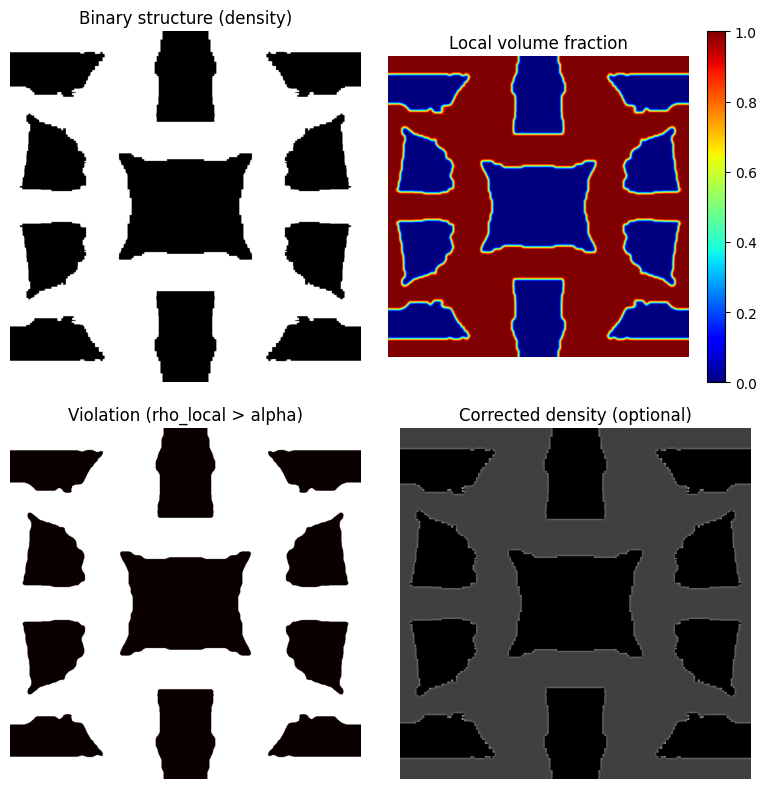

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. ĐỌC ẢNH ĐEN TRẮNG → MAP SANG DENSITY (0–1)
# =========================================================
img = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)
vsymmetric = vertical_symmetric(img)
hsymmetric = horizontal_symmetric(vsymmetric)
csymmetric = centripetal_symmetric(hsymmetric)
img = csymmetric
if img is None:
    raise ValueError("Không đọc được ảnh. Kiểm tra lại đường dẫn!")

contours, _ = cv2.findContours(
    img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)
small_area = 1000
removed = 0
for cnt in contours:
    if cv2.contourArea(cnt) < small_area:
        cv2.drawContours(img, [cnt], -1, 0, thickness=-1)
        removed += 1
if removed:
    print(f"Filled {removed} tiny contours (area < {small_area})")

# Nhị phân hóa (phòng trường hợp ảnh chưa chuẩn)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Vật liệu = 1 (đen), rỗng = 0 (trắng)
rho = (binary == 0).astype(np.float32)

# =========================================================
# 2. THAM SỐ KIỂM SOÁT PHÂN BỐ CỤC BỘ
# =========================================================
Rl = 8       # bán kính local region (pixel)
alpha = 0.25  # ngưỡng local volume fraction

# =========================================================
# 3. TÍNH LOCAL VOLUME FRACTION (Eq. 8)
# =========================================================
def compute_local_volume_fraction(rho, R):
    h, w = rho.shape
    rho_local = np.zeros_like(rho)

    # Kernel tròn
    Y, X = np.ogrid[-R:R+1, -R:R+1]
    mask = (X**2 + Y**2) <= R**2

    for y in range(h):
        for x in range(w):
            y0 = max(0, y - R)
            y1 = min(h, y + R + 1)
            x0 = max(0, x - R)
            x1 = min(w, x + R + 1)

            sub = rho[y0:y1, x0:x1]
            mask_sub = mask[
                (y0 - y + R):(y1 - y + R),
                (x0 - x + R):(x1 - x + R)
            ]

            rho_local[y, x] = np.sum(sub * mask_sub) / np.sum(mask_sub)

    return rho_local

rho_local = compute_local_volume_fraction(rho, Rl)

# =========================================================
# 4. PHÁT HIỆN VÙNG VI PHẠM PHÂN BỐ CỤC BỘ
# =========================================================
violation = rho_local > alpha

# =========================================================
# 5. (TUỲ CHỌN) LÀM MỀM / PHẠT VÙNG QUÁ ĐẶC
# =========================================================
rho_corrected = rho.copy()
rho_corrected[violation] *= alpha / rho_local[violation]

# =========================================================
# 6. HIỂN THỊ KẾT QUẢ
# =========================================================
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.title("Binary structure (density)")
plt.imshow(rho, cmap="gray")
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Local volume fraction")
plt.imshow(rho_local, cmap="jet")
plt.colorbar()
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Violation (rho_local > alpha)")
plt.imshow(violation, cmap="hot")
plt.axis("off")

plt.subplot(2,2,4)
plt.title("Corrected density (optional)")
plt.imshow(rho_corrected, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()


Filled 12 tiny contours (area < 1000)
Initial g4 = 0.6764254852118015
max rho_l = 1.0000000000000173
Iter 0: g4 = 0.6764
Initial g4 = 0.6764250103498621
max rho_l = 0.9999998075959271
Iter 1: g4 = 0.6764
Initial g4 = 0.6764245354880796
max rho_l = 0.999999615191207
Iter 2: g4 = 0.6764
Initial g4 = 0.6764240606264539
max rho_l = 0.9999994227858551
Iter 3: g4 = 0.6764
Initial g4 = 0.6764235857649848
max rho_l = 0.9999992303798715
Iter 4: g4 = 0.6764
Initial g4 = 0.6764231109036727
max rho_l = 0.999999037973256
Iter 5: g4 = 0.6764
Initial g4 = 0.6764226360425172
max rho_l = 0.9999988455660089
Iter 6: g4 = 0.6764
Initial g4 = 0.6764221611815185
max rho_l = 0.99999865315813
Iter 7: g4 = 0.6764
Initial g4 = 0.6764216863206767
max rho_l = 0.9999984607496188
Iter 8: g4 = 0.6764
Initial g4 = 0.6764212114599915
max rho_l = 0.9999982683404764
Iter 9: g4 = 0.6764
Initial g4 = 0.676420736599463
max rho_l = 0.9999980759307019
Iter 10: g4 = 0.6764
Initial g4 = 0.6764202617390914
max rho_l = 0.9999978

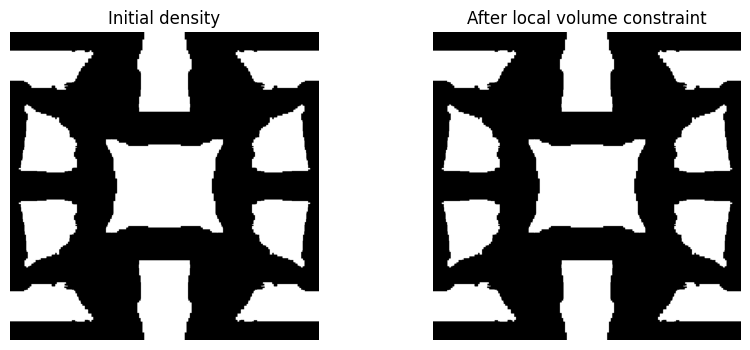

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc ảnh
img = cv2.imread("/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png", cv2.IMREAD_GRAYSCALE)
vsymmetric = vertical_symmetric(img)
hsymmetric = horizontal_symmetric(vsymmetric)
csymmetric = centripetal_symmetric(hsymmetric)
img = csymmetric
if img is None:
    raise ValueError("Không đọc được ảnh. Kiểm tra lại đường dẫn!")

contours, _ = cv2.findContours(
    img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)
small_area = 1000
removed = 0
for cnt in contours:
    if cv2.contourArea(cnt) < small_area:
        cv2.drawContours(img, [cnt], -1, 0, thickness=-1)
        removed += 1
if removed:
    print(f"Filled {removed} tiny contours (area < {small_area})")
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# mật độ thiết kế: material = 1, void = 0
rho = img.astype(np.float64) / 255.0



Rl = 12          # bán kính local region
alpha = 0.25    # giới hạn local volume
q = 15
lr = 0.2       # learning rate
n_iter = 30

Y, X = np.ogrid[-Rl:Rl+1, -Rl:Rl+1]
kernel = ((X**2 + Y**2) <= Rl**2).astype(float)
kernel /= kernel.sum()

def local_volume(rho, kernel):
    return cv2.filter2D(rho, -1, kernel)

def pnorm_constraint(rho_l, q, alpha):
    g = (np.mean(rho_l**q))**(1/q) - alpha
    return g

def grad_pnorm(rho, rho_l, kernel, q):
    N = rho.size
    A = np.mean(rho_l**q)
    coeff = (1/N) * A**(1/q - 1)
    dgl = coeff * (rho_l**(q-1))

    # chain rule: ∂ρᶩ / ∂ρ
    grad = cv2.filter2D(dgl, -1, kernel)
    return grad

for it in range(n_iter):
    rho_l = local_volume(rho, kernel)
    g4 = pnorm_constraint(rho_l, q, alpha)
    print("Initial g4 =", g4)
    print("max rho_l =", rho_l.max())

    if g4 <= 0:
        print(f"Iter {it}: constraint satisfied")
        break

    grad = grad_pnorm(rho, rho_l, kernel, q)

    # cập nhật mật độ
    rho -= lr * grad
    rho = np.clip(rho, 0.0, 1.0)

    print(f"Iter {it}: g4 = {g4:.4f}")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Initial density")
plt.imshow((binary == 255), cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After local volume constraint")
plt.imshow(rho, cmap="gray")
plt.axis("off")

plt.show()


/var/folders/q4/rx50kftn5p15zgc30fx74cjm0000gn/T/ipykernel_80456/2714859651.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vx, vy, x0, y0 = float(vx), float(vy), float(x0), float(y0)


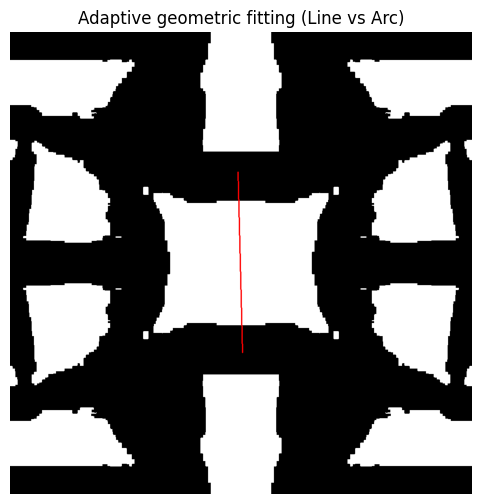

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. ĐỌC ẢNH & NHỊ PHÂN
# =========================================================
image_path = "/Users/raiju/Downloads/Shape_Initial_design_40/Hexagonal_2_2024-10-01_hexagonal_90_degree; volfrac=0.5; penal=3; rmin=3;/iteration_00067.png"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
v = vertical_symmetric(img)
s = horizontal_symmetric(v)
c = centripetal_symmetric(s)
img = c
if img is None:
    raise ValueError("Không đọc được ảnh!")

_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

# =========================================================
# 2. TÌM CONTOUR
# =========================================================
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
min_area = 1000
contours = [c for c in contours if cv2.contourArea(c) > min_area]

# =========================================================
# 3. HÀM HỖ TRỢ
# =========================================================
def resample_contour(cnt, n=400):
    pts = cnt[:, 0, :]
    d = np.sqrt(np.sum(np.diff(pts, axis=0)**2, axis=1))
    s = np.concatenate([[0], np.cumsum(d)])
    s /= s[-1]
    t = np.linspace(0, 1, n)
    x = np.interp(t, s, pts[:, 0])
    y = np.interp(t, s, pts[:, 1])
    return np.stack([x, y], axis=1)

def curvature(p):
    p_prev = np.roll(p, 1, axis=0)
    p_next = np.roll(p, -1, axis=0)
    v1 = p_prev - p
    v2 = p_next - p
    ang = np.arccos(np.clip(
        np.sum(v1 * v2, axis=1) /
        (np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1) + 1e-8),
        -1, 1))
    return ang

def split_segments(mask):
    segs = []
    start = 0
    for i in range(1, len(mask)):
        if mask[i] != mask[i-1]:
            segs.append((start, i))
            start = i
    segs.append((start, len(mask)))
    return segs

# =========================================================
# 4. FIT & ERROR
# =========================================================
def fit_line_err(pts):
    vx, vy, x0, y0 = cv2.fitLine(
        pts.astype(np.float32),
        cv2.DIST_L2, 0, 0.01, 0.01
    )
    vx, vy, x0, y0 = float(vx), float(vy), float(x0), float(y0)
    n = np.array([-vy, vx])
    d = np.abs((pts - np.array([x0, y0])) @ n)
    return d.mean(), (vx, vy, x0, y0)

def fit_circle_err(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.column_stack([2*x, 2*y, np.ones(len(x))])
    b = x**2 + y**2
    c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    xc, yc, r2 = c
    R = np.sqrt(r2 + xc**2 + yc**2)
    Ri = np.sqrt((x-xc)**2 + (y-yc)**2)
    err = np.abs(Ri - R)
    return err.mean(), (xc, yc, R), Ri

# =========================================================
# 5. ADAPTIVE GEOMETRIC FITTING (HƯỚNG A)
# =========================================================
canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
H, W = img.shape
R_MAX = 0.8 * max(H, W)

for cnt in contours:
    pts = resample_contour(cnt)
    k = curvature(pts)

    # change-point detection
    th = np.percentile(k, 60)
    mask = k > th
    segments = split_segments(mask)

    for s, e in segments:
        seg = pts[s:e]
        if len(seg) < 25:
            continue

        err_l, line = fit_line_err(seg)
        err_c, (xc, yc, R), Ri = fit_circle_err(seg)

        # ---- RÀNG BUỘC ARC ----
        arc_ok = (
            np.std(Ri) / np.mean(Ri) < 0.05 and   # bán kính ổn định
            R < R_MAX                              # không phải arc toàn cục
        )

        # ---- CHỌN MÔ HÌNH ----
        if arc_ok and err_c < err_l:
            theta = np.arctan2(seg[:,1]-yc, seg[:,0]-xc)
            theta = np.sort(theta)
            th_fit = np.linspace(theta[0], theta[-1], 120)
            arc = np.stack([
                xc + R*np.cos(th_fit),
                yc + R*np.sin(th_fit)
            ], axis=1)
            cv2.polylines(canvas, [arc.astype(int)], False, (0,255,0), 2)
        else:
            vx, vy, x0, y0 = line
            t = np.array([-200, 200])
            line_fit = np.stack([x0+t*vx, y0+t*vy], axis=1)
            cv2.polylines(canvas, [line_fit.astype(int)], False, (255,0,0), 2)

# =========================================================
# 6. HIỂN THỊ
# =========================================================
plt.figure(figsize=(6,6))
plt.imshow(canvas)
plt.title("Adaptive geometric fitting (Line vs Arc)")
plt.axis("off")
plt.show()
